<a href="https://colab.research.google.com/github/DimpySingh001/stock-price-prediction/blob/main/Stock_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install yfinance pandas numpy scikit-learn matplotlib keras tensorflow


[*********************100%***********************]  1 of 1 completed


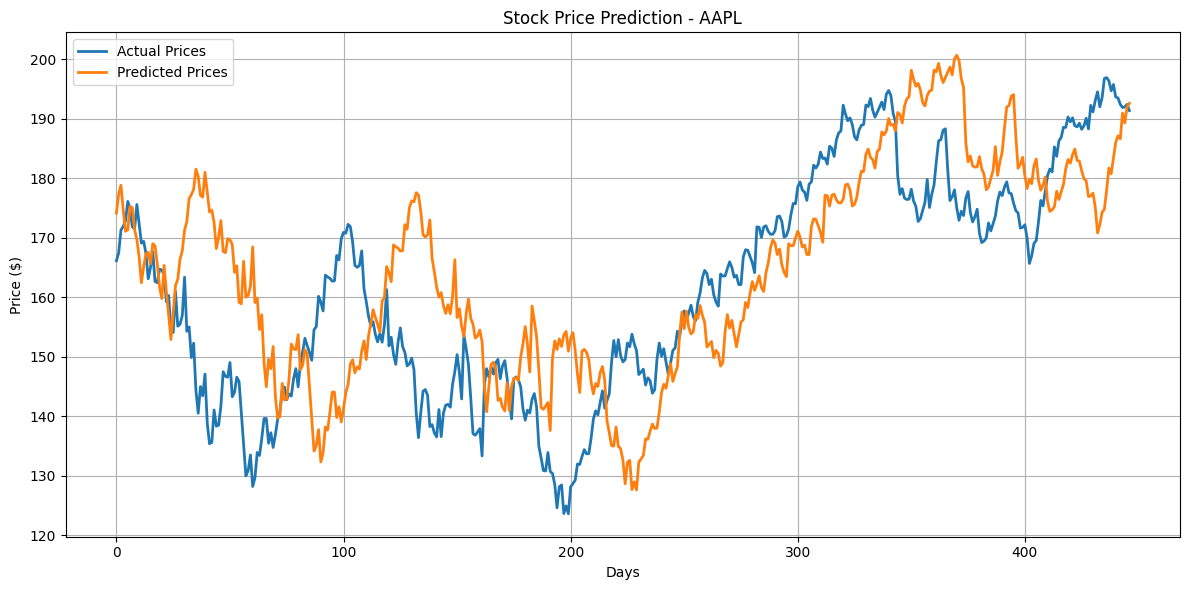

In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 1. Download stock data
stock = yf.download('AAPL', start='2015-01-01', end='2024-01-01')

stock = stock[['Close']]

# 2. Create features
stock['Prediction'] = stock[['Close']].shift(-30)  # Predict 30 days into the future

X = stock[['Close']][:-30]
y = stock['Prediction'][:-30]

# 3. Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# 4. Train model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Predict
predictions = model.predict(X_test)

# 6. Plot results
plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label='Actual Prices', linewidth=2)
plt.plot(predictions, label='Predicted Prices', linewidth=2)
plt.title('Stock Price Prediction - AAPL')
plt.xlabel('Days')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
